# ServLink — Service Co-occurrence Recommender: Training & Evaluation

Builds a NetworkX directed weighted graph over synthetic "booking session" data to power ServLink's cross-category AI suggestions (e.g. "customers who booked a house rental also booked an electrician"), replacing the hand-authored static suggestion lookup previously used on the search page.

In [1]:
import random
from collections import defaultdict

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 100)

## 1. Load the dataset

6,000 synthetic customer "sessions" (`generate_bookings.py`), each a small set of 1–4 service categories engaged together, sampled from hand-defined companion probabilities plus random noise. There's no real booking/browsing log yet since ServLink hasn't launched, so this bootstraps the graph until real data accumulates (see Limitations).

In [2]:
df = pd.read_csv("data/bookings.csv")
print(f"Total rows: {len(df)}")
print(f"Sessions: {df['session_id'].nunique()}")
print(f"Categories: {df['category'].nunique()}")
df.sample(8, random_state=1)

Total rows: 15018
Sessions: 6000
Categories: 8


,session_id,category
6203,2479,house-rental
13794,5506,movers
6834,2725,painter
11207,4464,carpenter
8033,3202,carpenter
7622,3040,electrician
107,40,painter
14613,5837,carpenter


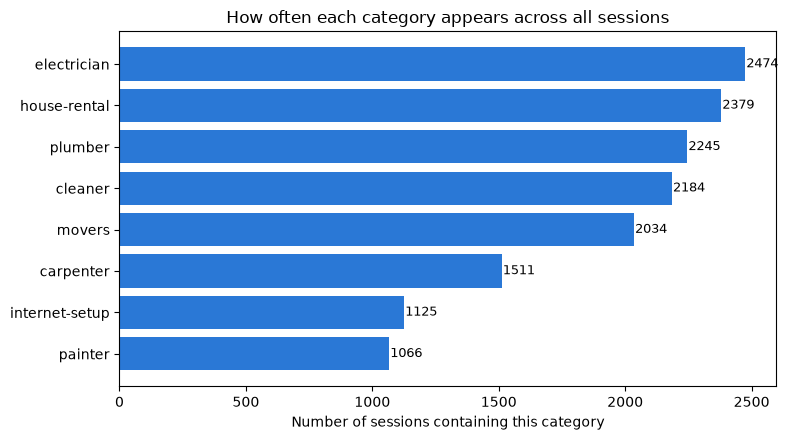

In [3]:
counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(counts.index[::-1], counts.values[::-1], color="#2a78d6")
ax.set_xlabel("Number of sessions containing this category")
ax.set_title("How often each category appears across all sessions")
for i, v in enumerate(counts.values[::-1]):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 2. Train / test split

80/20 split **by session** (not by row — every row from one session has to stay together), fixed random seed for reproducibility.

In [4]:
session_ids = df["session_id"].unique().tolist()
random.Random(42).shuffle(session_ids)
split_at = int(len(session_ids) * 0.8)
train_ids, test_ids = set(session_ids[:split_at]), set(session_ids[split_at:])

sessions = defaultdict(list)
for row in df.itertuples():
    sessions[row.session_id].append(row.category)

train_sessions = {sid: cats for sid, cats in sessions.items() if sid in train_ids}
test_sessions = {sid: cats for sid, cats in sessions.items() if sid in test_ids}
print(f"Train sessions: {len(train_sessions)}   Test sessions: {len(test_sessions)}")

Train sessions: 4800   Test sessions: 1200


## 3. Build the co-occurrence graph

For every pair of categories that appear together in a training session, add a directed edge `source -> target` weighted by the conditional probability P(target in session | source in session). Edges below `MIN_EDGE_WEIGHT` are dropped as noise.

In [5]:
MIN_EDGE_WEIGHT = 0.05

def build_graph(sessions):
    source_counts = defaultdict(int)
    pair_counts = defaultdict(int)
    for categories in sessions.values():
        unique = set(categories)
        for source in unique:
            source_counts[source] += 1
            for target in unique:
                if source != target:
                    pair_counts[(source, target)] += 1

    graph = nx.DiGraph()
    graph.add_nodes_from(source_counts.keys())
    for (source, target), count in pair_counts.items():
        weight = count / source_counts[source]
        if weight >= MIN_EDGE_WEIGHT:
            graph.add_edge(source, target, weight=round(weight, 4))
    return graph

graph = build_graph(train_sessions)
print(f"Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Graph: 8 nodes, 56 edges


## 4. Evaluate on held-out test sessions

For each category in a test session, does the graph's top-5 recommended companions overlap with the session's *other* categories?

- **precision@5** — of the 5 recommended slots, what share were actually relevant
- **recall@5** — of a session's true companion categories, what share were captured somewhere in the top 5

In [6]:
TOP_K = 5

def recommend(graph, category, k=TOP_K):
    if category not in graph:
        return []
    ranked = sorted(graph[category].items(), key=lambda item: -item[1]["weight"])
    return [target for target, _ in ranked[:k]]

hits, recommended_total, relevant_total, evaluated = 0, 0, 0, 0
for categories in test_sessions.values():
    unique = set(categories)
    for source in unique:
        true_companions = unique - {source}
        if not true_companions:
            continue
        top_k = set(recommend(graph, source))
        if not top_k:
            continue
        evaluated += 1
        hits += len(top_k & true_companions)
        recommended_total += len(top_k)
        relevant_total += len(true_companions)

precision_at_5 = hits / recommended_total
recall_at_5 = hits / relevant_total
print(f"PRECISION@5: {precision_at_5:.2%}")
print(f"RECALL@5:    {recall_at_5:.2%}")
print(f"Evaluated {evaluated} (session, category) pairs across {len(test_sessions)} test sessions")

PRECISION@5: 38.88%
RECALL@5:    90.18%
Evaluated 2779 (session, category) pairs across 1200 test sessions


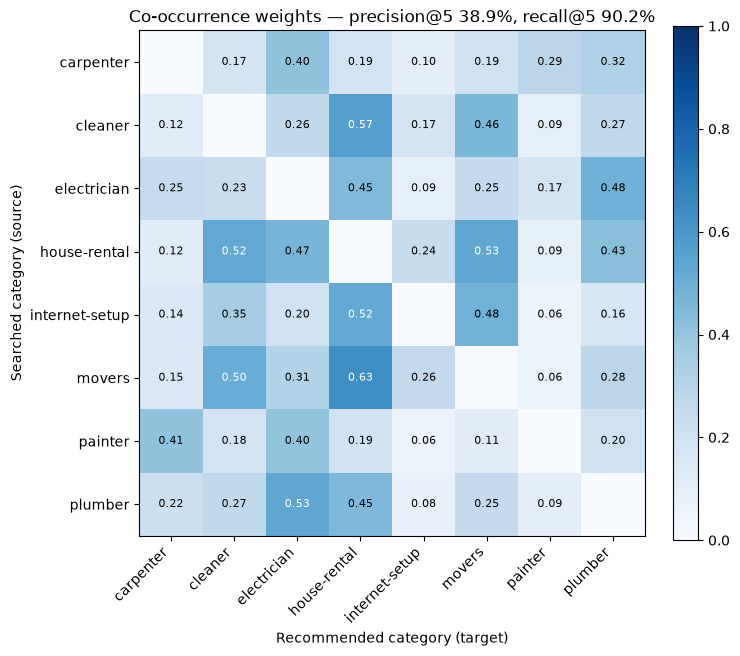

In [7]:
categories = sorted(graph.nodes)
matrix = pd.DataFrame(0.0, index=categories, columns=categories)
for source in categories:
    for target in categories:
        if graph.has_edge(source, target):
            matrix.loc[source, target] = graph[source][target]["weight"]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
im = ax.imshow(matrix.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(categories))); ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_yticks(range(len(categories))); ax.set_yticklabels(categories)
ax.set_xlabel("Recommended category (target)")
ax.set_ylabel("Searched category (source)")
ax.set_title(f"Co-occurrence weights — precision@5 {precision_at_5:.1%}, recall@5 {recall_at_5:.1%}")
for i in range(len(categories)):
    for j in range(len(categories)):
        v = matrix.values[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 5. Try it yourself

Edit `test_category` below and re-run the cell to see live recommendations.

In [8]:
test_category = "movers"  # <-- edit this and re-run

print(f'"{test_category}"\n')
for target in recommend(graph, test_category, k=8):
    w = graph[test_category][target]["weight"]
    bar = "#" * int(w * 40)
    print(f"  {target:15s} {w:.2%}  {bar}")

"movers"

  house-rental    63.40%  #########################
  cleaner         50.47%  ####################
  electrician     31.29%  ############
  plumber         28.48%  ###########
  internet-setup  26.11%  ##########
  carpenter       14.74%  #####
  painter         6.00%  ##


## 6. Inspecting the saved graph file

`model/recommend_graph.json` is NetworkX's node-link JSON serialization, not the `graph` variable already in memory above. This loads it **fresh from disk** to confirm it's exactly the same file `backend/app/main.py` (and the personalized recommender in `backend/app/routers/search_log.py`) load when the API server starts.

In [9]:
import json

with open("model/recommend_graph.json", encoding="utf-8") as f:
    loaded_graph = nx.node_link_graph(json.load(f), edges="edges")

print("Object type:", type(loaded_graph))
print("Nodes:", sorted(loaded_graph.nodes))
print("Edges:", loaded_graph.number_of_edges())
print()
print("Sample edges from 'house-rental':")
for target, edge in sorted(loaded_graph["house-rental"].items(), key=lambda x: -x[1]["weight"]):
    print(f"  house-rental -> {target:15s} weight={edge['weight']}")

Object type: <class 'networkx.classes.digraph.DiGraph'>
Nodes: ['carpenter', 'cleaner', 'electrician', 'house-rental', 'internet-setup', 'movers', 'painter', 'plumber']
Edges: 56

Sample edges from 'house-rental':
  house-rental -> movers          weight=0.5342
  house-rental -> cleaner         weight=0.5242
  house-rental -> electrician     weight=0.4695
  house-rental -> plumber         weight=0.4253
  house-rental -> internet-setup  weight=0.2416
  house-rental -> carpenter       weight=0.1195
  house-rental -> painter         weight=0.0858


## Limitations & next steps

- **Small catalog caps precision.** With only 8 categories and 2–4 true companions per session, precision@5 is mechanically bounded well below 1.0 regardless of model quality — recall@5 is the more meaningful number for this catalog size.
- **Training data is entirely synthetic** — no real booking/browsing log exists yet since ServLink hasn't launched; the companion probabilities in `generate_bookings.py` were hand-designed to approximate plausible real-world bundles, not measured from actual behavior.
- **Some learned relationships are emergent, not hand-coded** — e.g. `movers -> electrician` isn't a direct companion rule in `generate_bookings.py`, but emerges because both categories are strongly linked to `house-rental` sessions.
- **Next step:** once real bookings accumulate, retrain on real session data instead of synthetic sessions, and expand beyond 8 categories for a more informative precision@5.

This notebook mirrors `generate_bookings.py` and `train_recommender.py`, which are what actually produce `model/recommend_graph.json` and `model/recommend_metrics.json` used by the live app (`backend/app/main.py`'s `/api/ai/recommend` and `backend/app/routers/search_log.py`'s `/api/ai/recommend/personalized`).